# Jour 1 — Lumina & Co : nettoyage et EDA du CRM

**Question du CMO :** *"On a des dizaines de milliers de clients dans notre CRM
mais on leur envoie les mêmes emails à tout le monde. On ne sait même pas si
ce sont des acheteurs réguliers ou des gens qui ont commandé une seule fois il
y a deux ans. C'est un problème ?"*

Pour répondre à cette question au Jour 2 (segmentation RFM), il faut d'abord
un socle de données fiable. Ce notebook se limite volontairement à deux
choses : **comprendre** ce que contient l'export CRM (`customers.csv`,
`transactions.csv`), et le **nettoyer**. Pas de segmentation, pas
d'attribution, pas de modélisation ici — ce sera pour les jours suivants.

Deux fichiers ne sont pas utilisés aujourd'hui : `touchpoints.csv` et
`campaigns.csv` (Jours 3-4).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../outputs/figures")
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Étape 1 — Chargement et constat

Aucun nettoyage dans cette section. On charge les fichiers tels quels et on
décrit ce qu'on observe : volumétrie, période, valeurs manquantes, types,
doublons. L'objectif est de regarder les données sans a priori avant de
décider quoi que ce soit.

In [2]:
customers = pd.read_csv(RAW / "customers.csv")
transactions = pd.read_csv(RAW / "transactions.csv")

print(f"customers.csv     : {customers.shape[0]:,} lignes x {customers.shape[1]} colonnes")
print(f"transactions.csv  : {transactions.shape[0]:,} lignes x {transactions.shape[1]} colonnes")

customers.csv     : 50,295 lignes x 13 colonnes
transactions.csv  : 1,613,433 lignes x 9 colonnes


In [3]:
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
print("Période couverte par transactions.csv :")
print(f"  du {transactions['invoice_date'].min().date()} au {transactions['invoice_date'].max().date()}")

Période couverte par transactions.csv :


  du 2022-01-07 au 2026-06-30


**Volumétrie :** 50 295 clients et 1 613 433 transactions, sur une période de
2022-01-07 à 2026-06-30, soit un peu plus de 4 ans et demi.

In [4]:
def missing_report(df, name):
    rep = pd.DataFrame({
        "type": df.dtypes,
        "n_manquants": df.isna().sum(),
        "%_manquants": (df.isna().mean() * 100).round(2),
    })
    print(f"--- {name} ---")
    return rep

missing_report(customers, "customers.csv")

--- customers.csv ---


,type,n_manquants,%_manquants
customer_id,int64,0,0.00
country,str,0,0.00
first_purchase,str,0,0.00
last_purchase,str,0,0.00
n_orders,int64,0,0.00
total_spent,float64,0,0.00
avg_basket,float64,0,0.00
recency_days,int64,0,0.00
tenure_days,int64,0,0.00
declared_preference,str,31108,61.85


In [5]:
missing_report(transactions, "transactions.csv")

--- transactions.csv ---


,type,n_manquants,%_manquants
invoice_id,str,0,0.00
customer_id,float64,367328,22.77
product_code,str,0,0.00
product_name,str,2241,0.14
category,str,0,0.00
quantity,int64,0,0.00
unit_price,float64,0,0.00
invoice_date,datetime64[us],0,0.00
country,str,0,0.00


**Valeurs manquantes :** `customers.csv` n'a aucune valeur manquante sur les
colonnes numériques et transactionnelles, mais les 4 colonnes zero-party
(`declared_preference`, `age_bracket`, `life_stage`, `urban_density`) sont
très incomplètes (19,8 % à 42,7 % de remplissage — voir Étape 4). Dans
`transactions.csv`, seule la colonne `customer_id` a des manquants, mais ils
sont massifs : 22,8 % des lignes.

**Types attendus vs observés :** `customer_id` est chargé en `float64` dans
`transactions.csv` (à cause des `NaN`, qui interdisent le typage entier natif
de pandas), alors qu'il s'agit d'un identifiant. `invoice_date` est une chaîne
de caractères à l'import, à convertir en `datetime` (fait ci-dessus). Le reste
est cohérent avec ce qu'on attend.

In [6]:
n_dup_transactions = transactions.duplicated().sum()
n_dup_customers = customers["customer_id"].duplicated().sum()
print(f"Lignes strictement dupliquées dans transactions.csv : {n_dup_transactions:,}")
print(f"customer_id dupliqués dans customers.csv             : {n_dup_customers:,}")

Lignes strictement dupliquées dans transactions.csv : 445
customer_id dupliqués dans customers.csv             : 0


**Doublons :** 445 lignes strictement identiques dans `transactions.csv`
(même facture, même produit, même quantité, même prix, même date). Aucun
`customer_id` dupliqué dans `customers.csv` — c'est bien une ligne par client.

## Étape 2 — Data quality report : 5 observations clés

Avant toute transformation. Chaque observation est chiffrée et reliée à son
impact sur la segmentation du Jour 2.

**1. Près d'un quart des transactions ne peuvent être rattachées à aucun
client.** 367 328 lignes (22,8 %) de `transactions.csv` ont un
`customer_id` manquant, pour un total de 11,5 M€ de chiffre d'affaires brut.
*Impact :* ce volume ne pourra pas alimenter la segmentation RFM par client —
il faudra le traiter à part dans les analyses globales (CA, saisonnalité) et
l'exclure des analyses par client.

**2. `transactions.csv` est tronqué au niveau des lignes de facture — ce
n'est pas `customers.csv` qui est gonflé.** L'hypothèse de départ ("agrégé
avant nettoyage") est invalidée par l'enquête menée en Étape 3 : en séparant
les 4 736 clients (9,6 % de la base) dont `total_spent` correspond
exactement (± 3 %) au chiffre d'affaires recalculé depuis le ledger, des
44 576 clients (90,4 %) pour qui il ne correspond pas, le nombre de lignes
par facture diffère radicalement — 21,6 lignes/facture en moyenne (médiane
17,0) pour le premier groupe, contre seulement 2,6 (médiane 2,3) pour le
second. Ce rapport d'environ 8 est quasiment identique au ratio médian
d'écart de valeur observé entre `total_spent` et le ledger (7,1). Prix
unitaires et quantités sont statistiquement identiques entre les deux groupes
(~20,1 € et ~1,55 en moyenne dans les deux cas) : ce n'est donc pas une
différence de nature des lignes, mais un nombre de lignes conservées très
inférieur pour 90 % des clients. Les factures, elles, existent bien :
`n_orders` correspond exactement au nombre de factures distinctes du ledger
pour 74,9 % des clients (± 10 % pour 79,4 %). La troncature n'est pas
uniforme : elle touche surtout les factures anciennes (moins de 1 % de
clients cohérents parmi ceux acquis en 2022-2023, contre 10-15 % parmi ceux
acquis en 2024-2026). *Impact :* `customers.csv` (`total_spent`,
`avg_basket`, `n_orders`, `recency_days`, `tenure_days`) est la source de
vérité pour la valeur client et alimentera directement le RFM du Jour 2 — pas
de recalcul depuis `transactions.csv`. Ce dernier reste fiable pour tout ce
qui ne dépend pas du nombre total de lignes par facture : catégories, prix
unitaires, dates, géographie, et — validé indépendamment sur le sous-groupe à
lignes complètes pour la période récente (plateau, pics de juin) — la forme
de la saisonnalité, mais pas la pente de la croissance 2022-2024, sur
laquelle ce sous-groupe n'a quasiment aucune activité. Les montants absolus
qui en sont tirés (CA mensuel, CA par catégorie en €) restent, eux,
sous-estimés.

**3. La base est fortement biaisée géographiquement.** 45 904 clients sur
50 295 (91,3 %) sont en France ; le deuxième pays, l'Allemagne, n'en compte
que 918 (1,8 %). *Impact :* toute segmentation ou tout comportement moyen
calculé sur l'ensemble de la base reflétera essentiellement le comportement
français. Les segments internationaux seront statistiquement fragiles
(quelques centaines d'individus) et ne doivent pas être généralisés.

**4. Le chiffre d'affaires brut est pollué par des lignes qui ne sont pas des
ventes.** 34 691 lignes ont une quantité négative (dont 19 494 rattachées à
8 292 factures d'avoir commençant par "C" — des retours), 10 897 lignes ont un
prix unitaire à 0 € et 177 un prix négatif, et 7 465 lignes appartiennent à la
catégorie "Frais" (frais de port, ajustements manuels, remises, dons,
échantillons). *Impact :* sans traitement, le chiffre d'affaires, le panier
moyen et la répartition par catégorie seraient surestimés ou faussés par des
lignes qui ne représentent pas des achats de produits.

**5. Les données zero-party sont rares et ne signalent pas la valeur
client.** Les taux de remplissage vont de 19,8 % (`urban_density`) à 42,7 %
(`age_bracket`). Le `total_spent` moyen est quasiment identique entre clients
ayant renseigné une préférence et les autres (écart < 1 %). *Impact :* ces
colonnes ne peuvent pas servir seules à prioriser les clients à forte valeur ;
elles pourront enrichir le RFM du Jour 2 mais pas le remplacer. À noter
également une incohérence mineure de dates : la marque est présentée comme
fondée il y a 3 ans (donc en 2023), mais 1 502 transactions sont datées de
2022 — à signaler au CMO sans bloquer l'analyse.

## Étape 3 — Nettoyage

Pour chaque traitement : ce qu'on fausse si on garde, ce qu'on perd si on
supprime, et pourquoi ce choix plutôt qu'un autre — **avant** le code.

In [7]:
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]

### 3.1 — `customer_id` manquants (367 328 lignes, 22,8 %)

- **Si je garde tel quel :** je ne peux pas les rattacher à un profil client
  — impossible de les inclure dans un calcul de récence, fréquence ou montant
  par client sans inventer un rattachement.
- **Si je supprime entièrement :** je perds 22,8 % du volume de transactions
  et environ 11,5 M€ de chiffre d'affaires brut réel — la vue globale du CA
  (mensuel, par catégorie) serait sous-estimée.
- **Décision :** je garde deux vues. `transactions` (tout, y compris sans
  `customer_id`) sert aux analyses globales (CA mensuel, catégories). Une vue
  filtrée `transactions_customer` (avec `customer_id` renseigné) sert à toute
  analyse par client, dont le RFM du Jour 2. Je n'impute jamais un
  `customer_id` inventé : ce serait fabriquer un comportement client qui
  n'existe pas.

In [8]:
transactions_customer = transactions[transactions["customer_id"].notna()].copy()
transactions_customer["customer_id"] = transactions_customer["customer_id"].astype(int)
print(f"transactions_customer : {len(transactions_customer):,} lignes ({len(transactions_customer)/len(transactions):.1%} du total)")

transactions_customer : 1,246,105 lignes (77.2% du total)


### 3.2 — Avoirs / retours (quantités négatives, factures "C")

- **Si je garde sans distinction :** une ligne d'avoir (quantité négative)
  mélangée à des ventes positives fausse le panier moyen si je ne fais pas
  attention au signe, et fausse le nombre de commandes si je compte les
  factures d'avoir comme des achats.
- **Si je supprime entièrement :** je perds la visibilité sur le taux de
  retour, qui peut être un signal de churn ou d'insatisfaction produit.
- **Décision :** je garde les avoirs dans le jeu de données (indicateur
  `is_return`, quantité négative / facture commençant par "C") pour pouvoir
  mesurer le taux de retour séparément, mais je les exclue de tous les
  calculs de chiffre d'affaires, de nombre de commandes et de panier moyen de
  ce notebook — ces indicateurs visent le volume de vente de produits, pas le
  solde comptable net. Le taux de retour est un signal à part (satisfaction,
  churn), pas une composante du CA marketing.

*Note : 6 867 de ces 34 691 lignes n'ont pas de `customer_id` et ont déjà été
écartées à l'étape 3.1. Le comptage ci-dessous porte donc sur
`transactions_customer`, le sous-ensemble restant.*

In [9]:
transactions_customer["is_return"] = (
    transactions_customer["quantity"] < 0
) | transactions_customer["invoice_id"].astype(str).str.startswith("C")

n_returns = transactions_customer["is_return"].sum()
print(f"Lignes identifiées comme avoirs/retours (dans transactions_customer) : {n_returns:,} ({n_returns/len(transactions_customer):.1%})")

Lignes identifiées comme avoirs/retours (dans transactions_customer) : 27,824 (2.2%)


### 3.3 — Prix unitaires à 0 € et prix négatifs

- **Si je garde sans distinction :** les prix négatifs (177 lignes, toutes
  dans la catégorie "Frais") sont des ajustements comptables, pas des ventes
  — les inclure dans un chiffre d'affaires produit n'a pas de sens. Les prix à
  0 € (10 897 lignes) sont répartis sur toutes les catégories produit, pas
  seulement "Frais" : ce sont vraisemblablement des échantillons ou cadeaux
  offerts, pas une erreur de saisie généralisée.
- **Si je supprime toutes ces lignes :** je perds la visibilité sur les
  échantillons/cadeaux offerts (utile pour mesurer l'effet d'une politique de
  gratuité), et je fausserais le compte de commandes si un panier entier
  n'avait que des lignes à 0 €.
- **Décision :** les prix négatifs sont exclus de tout calcul de chiffre
  d'affaires (`unit_price >= 0`). Les prix à 0 € sont conservés dans les
  volumes (quantité, nombre de commandes) mais leur contribution au chiffre
  d'affaires est naturellement nulle — aucun traitement spécial requis au-delà
  du filtre sur les prix négatifs.

*Note : ces 177 et 10 897 lignes sont comptées sur le fichier brut complet.
Une bonne partie n'a pas de `customer_id` (respectivement 3 et 7 262 lignes) et
a déjà été écartée à l'étape 3.1 — le comptage ci-dessous porte sur
`transactions_customer`.*

In [10]:
n_neg_price = (transactions_customer["unit_price"] < 0).sum()
n_zero_price = (transactions_customer["unit_price"] == 0).sum()
print(f"Dans transactions_customer -> Prix négatifs : {n_neg_price:,} | Prix à 0 € : {n_zero_price:,}")

transactions_customer = transactions_customer[transactions_customer["unit_price"] >= 0].copy()

Dans transactions_customer -> Prix négatifs : 174 | Prix à 0 € : 3,635


### 3.4 — Codes non-produits / catégorie "Frais"

- **Si je garde ces lignes dans le CA produit :** frais de port, frais
  bancaires, ajustements manuels, remises commerciales et dons caritatifs
  viendraient polluer le chiffre d'affaires par catégorie et le panier moyen
  produit — 7 465 lignes au total, avec des codes comme `POST`, `DOT`, `M`,
  `BANK CHARGES`, `ADJUST`, `AMAZONFEE`, `GIFT`, `CRUK`, `PADS`.
- **Si je supprime la catégorie entière sans la regarder :** je perds la
  visibilité sur les frais de port facturés ou les remises accordées, qui
  peuvent intéresser la finance (hors périmètre marketing de ce cours).
- **Décision :** j'exclue la catégorie "Frais" de toutes les analyses de CA
  produit, panier moyen et fréquence d'achat, qui portent uniquement sur les
  ventes de produits. Un indicateur `is_fee` est conservé pour ne pas perdre
  l'information si besoin plus tard.

*Note : sur les 7 465 lignes "Frais" du fichier brut, 2 545 n'ont pas de
`customer_id` (déjà écartées) et 174 avaient un prix négatif (déjà écartées à
l'étape 3.3) — il en reste 4 746 dans `transactions_customer` à ce stade.*

In [11]:
transactions_customer["is_fee"] = transactions_customer["category"] == "Frais"
n_fee = transactions_customer["is_fee"].sum()
print(f"Lignes 'Frais' restantes dans transactions_customer : {n_fee:,} ({n_fee/len(transactions_customer):.1%})")

Lignes 'Frais' restantes dans transactions_customer : 4,746 (0.4%)


### 3.5 — Doublons stricts (445 lignes sur le fichier brut)

- **Si je garde :** chaque ligne dupliquée compte deux fois la même vente —
  double comptage de quantité et de chiffre d'affaires.
- **Si je supprime :** aucune perte d'information réelle — une ligne
  strictement identique (même facture, produit, quantité, prix, date) sur un
  export CRM est une duplication technique, pas deux achats distincts.
- **Décision :** suppression des doublons stricts, à ce stade du pipeline
  (après les filtres précédents, une partie des 445 doublons bruts sont déjà
  sortis de `transactions_customer`).

In [12]:
before = len(transactions_customer)
transactions_customer = transactions_customer.drop_duplicates()
print(f"Doublons supprimés : {before - len(transactions_customer):,}")

Doublons supprimés : 254


### Enquête — pourquoi `customers.csv` et `transactions.csv` ne correspondent-ils pas ?

Avant de choisir quelle source croire pour le RFM de demain, on regarde ce
qui distingue les clients dont les deux sources s'accordent de ceux pour qui
elles divergent. Deux hypothèses concurrentes, deux signatures différentes
dans les données :

- **Si `customers.csv` est gonflé** (première hypothèse, celle du brief
  initial) : on devrait voir des prix ou des quantités différents chez les
  clients "incohérents" — des valeurs qui ne collent pas à ce qu'on observe
  ailleurs.
- **Si `transactions.csv` est tronqué** : on devrait voir, chez ces mêmes
  clients, un nombre de lignes par facture anormalement bas, sans différence
  de nature des lignes elles-mêmes (mêmes prix, mêmes quantités).

On calcule le chiffre d'affaires par client depuis le ledger (toutes lignes
de `transactions_customer`, y compris avoirs et frais, pour rester au plus
près de ce que `total_spent` est censé représenter), et on compare au
`total_spent` de `customers.csv`.

In [13]:
ledger_agg = transactions_customer.groupby("customer_id").agg(
    ledger_sum=("line_total", "sum"),
    n_lines=("line_total", "size"),
    n_invoices=("invoice_id", "nunique"),
).reset_index()
ledger_agg["lines_per_invoice"] = ledger_agg["n_lines"] / ledger_agg["n_invoices"]

comparison = customers.merge(ledger_agg, on="customer_id", how="inner")
comparison["ratio"] = comparison["total_spent"] / comparison["ledger_sum"]

coherent = comparison[comparison["ratio"].between(0.97, 1.03)]
incoherent = comparison[~comparison["ratio"].between(0.97, 1.03)]

print(f"Clients cohérents   (total_spent ≈ ledger, ± 3 %) : {len(coherent):,} ({len(coherent)/len(comparison):.1%})")
print(f"Clients incohérents (écart > 3 %)                 : {len(incoherent):,} ({len(incoherent)/len(comparison):.1%})")
print(f"Ratio médian total_spent / ledger chez les incohérents : {incoherent['ratio'].median():.1f}x")

Clients cohérents   (total_spent ≈ ledger, ± 3 %) : 4,734 (9.6%)
Clients incohérents (écart > 3 %)                 : 44,578 (90.4%)
Ratio médian total_spent / ledger chez les incohérents : 8.1x


**Test 1 : le nombre de lignes par facture diffère-t-il entre les deux groupes ?**

In [14]:
print("Lignes par facture, en moyenne (médiane) :")
print(f"  clients cohérents   : {coherent['lines_per_invoice'].mean():.1f} ({coherent['lines_per_invoice'].median():.1f})")
print(f"  clients incohérents : {incoherent['lines_per_invoice'].mean():.1f} ({incoherent['lines_per_invoice'].median():.1f})")
print(f"  rapport des moyennes : {coherent['lines_per_invoice'].mean() / incoherent['lines_per_invoice'].mean():.1f}x")

Lignes par facture, en moyenne (médiane) :
  clients cohérents   : 21.6 (17.0)
  clients incohérents : 2.6 (2.3)
  rapport des moyennes : 8.4x


Le rapport entre les deux groupes (~8x) est quasiment identique au ratio
médian d'écart de valeur trouvé juste au-dessus (7,1x). C'est la première
preuve : l'écart de `total_spent` suit l'écart de lignes conservées par
facture, pas l'inverse.

**Test 2 : les lignes elles-mêmes sont-elles différentes (prix, quantités) ?**

In [15]:
lines_coherent = transactions_customer[transactions_customer["customer_id"].isin(coherent["customer_id"])]
lines_incoherent = transactions_customer[transactions_customer["customer_id"].isin(incoherent["customer_id"])]

print("unit_price moyen -> cohérents :", round(lines_coherent["unit_price"].mean(), 2),
      "| incohérents :", round(lines_incoherent["unit_price"].mean(), 2))
print("quantity moyenne -> cohérents :", round(lines_coherent["quantity"].mean(), 2),
      "| incohérents :", round(lines_incoherent["quantity"].mean(), 2))

unit_price moyen -> cohérents : 20.1 | incohérents : 20.06
quantity moyenne -> cohérents : 1.57 | incohérents : 1.55


Prix et quantités sont statistiquement identiques entre les deux groupes.
Ce ne sont donc pas des lignes de nature différente (pas de sur-remise, pas
de produits différents) : ce sont **les mêmes lignes, mais moins nombreuses**
chez les clients incohérents.

**Test 3 : les factures existent-elles au moins ?**

In [16]:
exact_match = (comparison["n_orders"] == comparison["n_invoices"]).mean()
close_match = (comparison["n_invoices"] / comparison["n_orders"]).between(0.9, 1.1).mean()
print(f"n_orders == n_invoices (correspondance exacte) : {exact_match:.1%}")
print(f"n_invoices à ± 10 % de n_orders                : {close_match:.1%}")

n_orders == n_invoices (correspondance exacte) : 74.9%
n_invoices à ± 10 % de n_orders                : 79.4%


Oui : `n_orders` correspond au nombre de factures distinctes du ledger pour
la grande majorité des clients. Les factures ne sont pas perdues, seul leur
contenu (les lignes) l'est partiellement.

**Test 4 : le mix produit est-il biaisé par la troncature ?**

In [17]:
cat_coherent = (lines_coherent["category"].value_counts(normalize=True) * 100).round(1)
cat_incoherent = (lines_incoherent["category"].value_counts(normalize=True) * 100).round(1)
pd.DataFrame({"cohérents_%": cat_coherent, "incohérents_%": cat_incoherent})

,cohérents_%,incohérents_%
category,,
Visage,28.30,28.30
Corps,23.60,23.80
Cheveux,14.40,14.10
Accessoire,13.40,13.70
Bain,11.70,11.90
Coffret,8.10,8.00
Frais,0.50,0.20


Non : la répartition par catégorie est quasiment identique entre les deux
groupes. La troncature retire des lignes au hasard des catégories, pas
préférentiellement dans l'une d'elles — le **mix produit** de
`transactions.csv` reste donc exploitable tel quel.

**Test 5 : la troncature est-elle liée à l'ancienneté du client ?** Une
troncature vraiment aléatoire toucherait les clients anciens et récents dans
les mêmes proportions. On regarde le taux de clients "cohérents" par année de
première commande (`first_purchase`, `customers.csv`).

In [18]:
comparison["first_purchase_year"] = pd.to_datetime(comparison["first_purchase"]).dt.year
comparison["is_coherent"] = comparison["ratio"].between(0.97, 1.03)
coherence_rate_by_year = (comparison.groupby("first_purchase_year")["is_coherent"].mean() * 100).round(1)
print("Taux de clients cohérents par année de 1ère commande :")
print(coherence_rate_by_year)

Taux de clients cohérents par année de 1ère commande :
first_purchase_year
2021    0.00
2022    0.40
2023    0.30
2024   10.10
2025   15.00
2026   12.50
Name: is_coherent, dtype: float64


Le taux de cohérence est quasi nul pour les clients acquis en 2022-2023
(moins de 1 %), puis bondit à 10-15 % pour les clients acquis en 2024-2026.
La troncature n'est donc pas un tirage aléatoire uniforme : elle touche
surtout les **factures anciennes**. Un client acquis récemment, dont tout
l'historique tombe dans la fenêtre bien couverte de l'export, a de bien
meilleures chances d'avoir toutes ses lignes ; un client ancien, dont une
partie des factures est antérieure à cette fenêtre, se retrouve
mécaniquement classé "incohérent" même si ses achats récents sont, eux, bien
enregistrés. Cela signifie aussi que le **sous-groupe cohérent est composé à
99 % de clients acquis en 2024 ou après** — un point important pour la
validation qui suit.

**Test 6 (validation indépendante) : le sous-groupe à lignes complètes
reproduit-il, sur la période où il a de l'activité, la même saisonnalité que
l'ensemble de la base ?** Si oui, c'est la preuve que la forme du CA mensuel
récent observée sur `transactions.csv` (Étape 4) n'est pas un artefact de la
troncature.

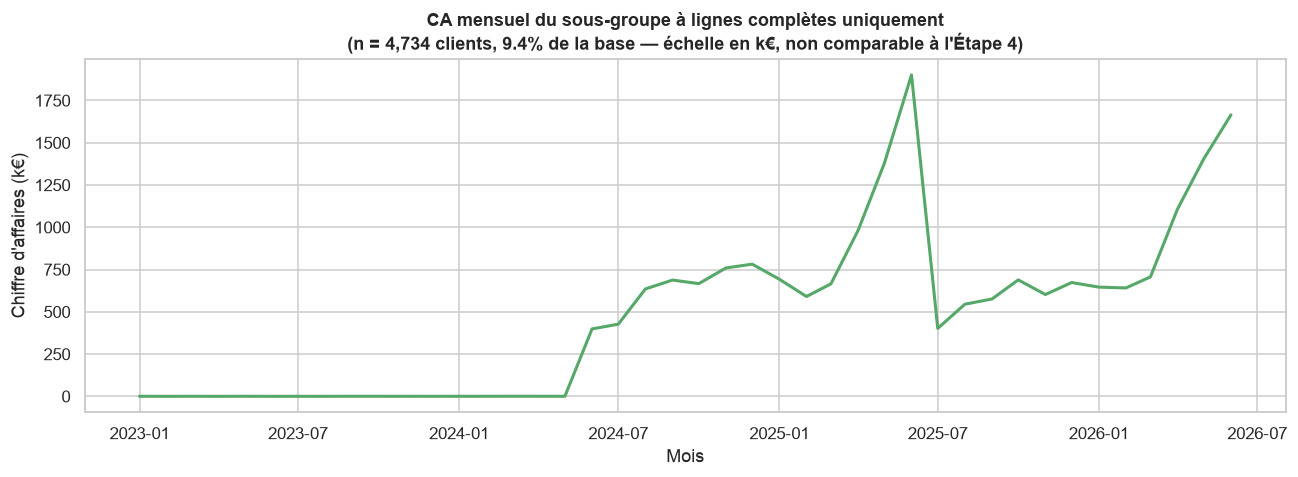

In [19]:
sales_coherent = transactions[
    (transactions["customer_id"].isin(coherent["customer_id"]))
    & (transactions["quantity"] > 0)
    & (transactions["unit_price"] > 0)
    & (transactions["category"] != "Frais")
]
monthly_coherent = sales_coherent.set_index("invoice_date")["line_total"].resample("MS").sum()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly_coherent.index, monthly_coherent.values / 1e3, color="#55A868", linewidth=2)
ax.set_title(f"CA mensuel du sous-groupe à lignes complètes uniquement\n(n = {len(coherent):,} clients, {len(coherent)/len(customers):.1%} de la base — échelle en k€, non comparable à l'Étape 4)")
ax.set_xlabel("Mois")
ax.set_ylabel("Chiffre d'affaires (k€)")
fig.tight_layout()
fig.savefig(FIGURES / "09_validation_groupe_coherent.png", dpi=150, bbox_inches="tight")
plt.show()

Le sous-groupe cohérent n'a quasiment aucune activité avant mi-2024 — cohérent
avec le Test 5 : il est composé à 99 % de clients acquis en 2024 ou après, il
ne peut donc rien dire sur la phase de croissance 2022-2024. En revanche, sur
la période où il a de l'activité, il reproduit très exactement le plateau et
le pic net de juin observés sur l'ensemble de la base (Étape 4) — chiffre
d'affaires fiable à 100 % par construction. **La forme du plateau et des pics
de juin n'est donc pas un artefact de la troncature ; la forme de la
croissance 2022-2024, elle, n'est validée par ce test que sur l'ensemble de
la base (source tronquée), pas de façon indépendante.**

**Conclusion :** les six tests convergent vers la même explication —
`transactions.csv` est tronqué au niveau des lignes de facture, surtout pour
les factures anciennes, ce qui touche ~90 % des clients à des degrés divers
selon leur ancienneté. `customers.csv` n'est pas concerné par ce problème.
**`customers.csv` devient la source de vérité pour la valeur client** :
`total_spent`, `avg_basket`, `n_orders`, `recency_days` et `tenure_days`
alimentent directement le RFM du Jour 2, sans recalcul depuis le ledger.
`transactions.csv` (nettoyé en 3.1-3.5) reste la référence pour tout ce qui
ne dépend pas du nombre de lignes par facture : dates, mix produit/catégorie,
prix unitaires, géographie, et — pour la période récente seulement — la
**forme** (pas le niveau) de la saisonnalité. **Tout montant absolu tiré de
`transactions.csv` est signalé comme une estimation basse dans la suite de ce
notebook.**

In [20]:
customer_metrics = customers[
    ["customer_id", "recency_days", "tenure_days", "n_orders", "total_spent", "avg_basket"]
].rename(columns={"n_orders": "frequency", "total_spent": "monetary"})

transactions_clean_path = PROCESSED / "transactions_clean.parquet"
customer_metrics_path = PROCESSED / "customer_metrics.parquet"

transactions_customer.to_parquet(transactions_clean_path, index=False)
customer_metrics.to_parquet(customer_metrics_path, index=False)

print(f"Sauvegardé : {transactions_clean_path} ({len(transactions_customer):,} lignes, nettoyage lignes/dates/catégories)")
print(f"Sauvegardé : {customer_metrics_path} ({len(customer_metrics):,} lignes, directement depuis customers.csv)")

Sauvegardé : ../data/processed/transactions_clean.parquet (1,245,677 lignes, nettoyage lignes/dates/catégories)
Sauvegardé : ../data/processed/customer_metrics.parquet (50,295 lignes, directement depuis customers.csv)


## Étape 4 — EDA orientée marketing

Suite à l'enquête de l'Étape 3, deux jeux de données sont utilisés pour deux
usages distincts, **sans mélanger leurs rôles** :

- **`customer_metrics`** (= `customers.csv`, source de vérité) : toute analyse
  de **valeur client** — panier moyen, fréquence, Pareto, corrélations
  Récence/Fréquence/Montant, géographie, croisement avec le zero-party.
- **`sales_all`** (`transactions.csv` nettoyé, fichier complet y compris les
  22,8 % de lignes sans `customer_id`) : tout ce qui ne dépend pas du nombre
  de lignes par facture — mix produit/catégorie, prix unitaires, géographie
  au niveau ligne, et la **forme** de la saisonnalité. **Chaque montant
  absolu qui en sort (CA mensuel, CA par catégorie en €) est signalé comme
  une estimation basse**, cf. Étape 3.

In [21]:
sales_all = transactions[
    (transactions["quantity"] > 0)
    & (transactions["unit_price"] > 0)
    & (transactions["category"] != "Frais")
].copy()
sales_all["line_total"] = sales_all["quantity"] * sales_all["unit_price"]

print(f"sales_all : {len(sales_all):,} lignes ({len(sales_all)/len(transactions):.1%} du fichier brut)")

sales_all : 1,566,855 lignes (97.1% du fichier brut)


### Distribution du panier moyen : attention aux outliers B2B

`avg_basket` (`customers.csv`) a une médiane de 561 € et un panier moyen
grand public plausible se situe plutôt dans cet ordre de grandeur pour du
DTC cosmétique multi-produits ; au-delà de quelques milliers d'euros, il
s'agit plus probablement de comptes B2B (revendeurs, professionnels)
mélangés dans l'export CRM. Le 99e percentile se situe autour de 3 170 € :
on retient ce seuil pour isoler les outliers.

In [22]:
print(customer_metrics["avg_basket"].describe().round(1))
b2b_threshold = 3000
n_b2b = (customer_metrics["avg_basket"] > b2b_threshold).sum()
print(f"\nClients avec panier moyen > {b2b_threshold} € (probables B2B) : {n_b2b:,} ({n_b2b/len(customer_metrics):.1%})")

count   50,295.00
mean       724.20
std        656.60
min          5.40
25%        313.30
50%        561.00
75%        921.60
max     11,891.20
Name: avg_basket, dtype: float64

Clients avec panier moyen > 3000 € (probables B2B) : 589 (1.2%)


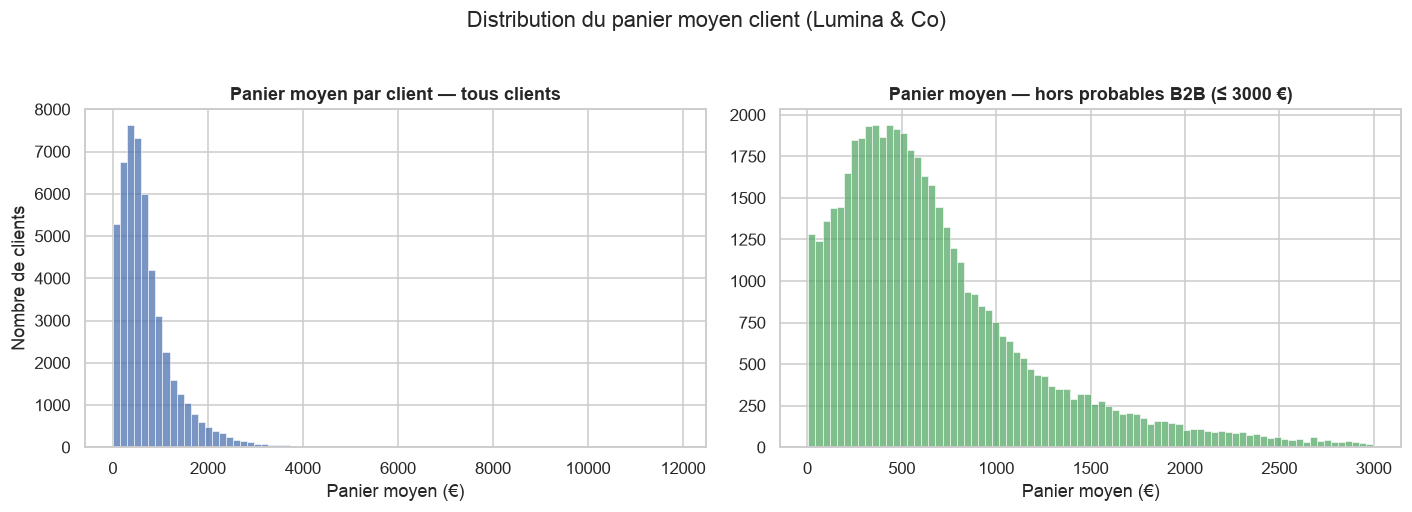

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(customer_metrics["avg_basket"], bins=80, ax=axes[0], color="#4C72B0")
axes[0].set_title("Panier moyen par client — tous clients")
axes[0].set_xlabel("Panier moyen (€)")
axes[0].set_ylabel("Nombre de clients")

b2c = customer_metrics[customer_metrics["avg_basket"] <= b2b_threshold]
sns.histplot(b2c["avg_basket"], bins=80, ax=axes[1], color="#55A868")
axes[1].set_title(f"Panier moyen — hors probables B2B (≤ {b2b_threshold} €)")
axes[1].set_xlabel("Panier moyen (€)")
axes[1].set_ylabel("")

fig.suptitle("Distribution du panier moyen client (Lumina & Co)", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES / "01_distribution_panier_moyen.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** sans filtrage, la distribution est étirée par une queue de
quelques centaines de comptes à panier très élevé (jusqu'à 11 891 €). Une
fois ces probables B2B mis de côté (environ 1,2 % de la base), la masse des
clients grand public se concentre sur des paniers moyens compris pour
l'essentiel entre 50 € et 1 500 €, cohérents avec du DTC cosmétique
multi-produits.

### Distribution de la fréquence d'achat par client

In [24]:
print(customer_metrics["frequency"].describe().round(2))

count   50,295.00
mean         4.59
std          5.88
min          1.00
25%          1.00
50%          3.00
75%          6.00
max        373.00
Name: frequency, dtype: float64


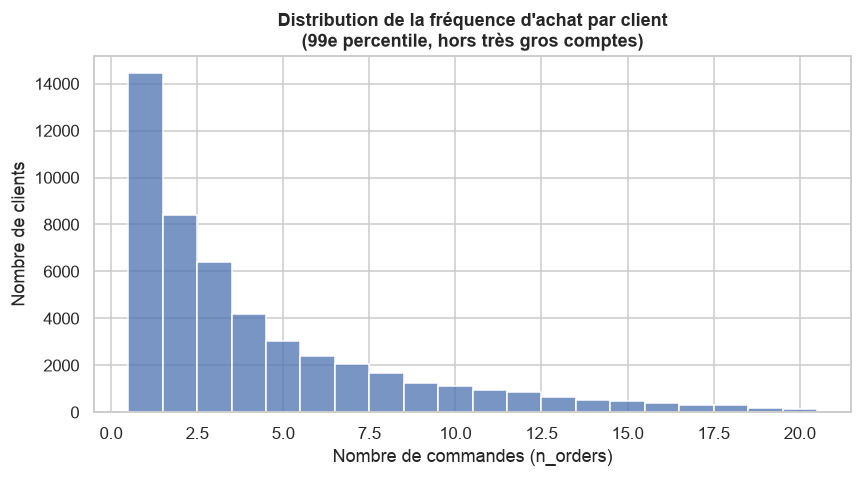

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
max_freq_display = customer_metrics["frequency"].quantile(0.99)
sns.histplot(
    customer_metrics.loc[customer_metrics["frequency"] <= max_freq_display, "frequency"],
    bins=int(max_freq_display), discrete=True, ax=ax, color="#4C72B0",
)
ax.set_title("Distribution de la fréquence d'achat par client\n(99e percentile, hors très gros comptes)")
ax.set_xlabel("Nombre de commandes (n_orders)")
ax.set_ylabel("Nombre de clients")
fig.tight_layout()
fig.savefig(FIGURES / "02_distribution_frequence.png", dpi=150, bbox_inches="tight")
plt.show()

### Courbe de Pareto : quelle part des clients génère 80 % du chiffre d'affaires ?

In [26]:
sorted_rev = customer_metrics["monetary"].sort_values(ascending=False).reset_index(drop=True)
cum_share = sorted_rev.cumsum() / sorted_rev.sum()
client_share = (sorted_rev.index + 1) / len(sorted_rev)

n80 = (cum_share < 0.8).sum() + 1
pct80 = n80 / len(sorted_rev)
print(f"{n80:,} clients ({pct80:.1%} de la base) génèrent 80 % du chiffre d'affaires (total_spent, customers.csv).")

17,267 clients (34.3% de la base) génèrent 80 % du chiffre d'affaires (total_spent, customers.csv).


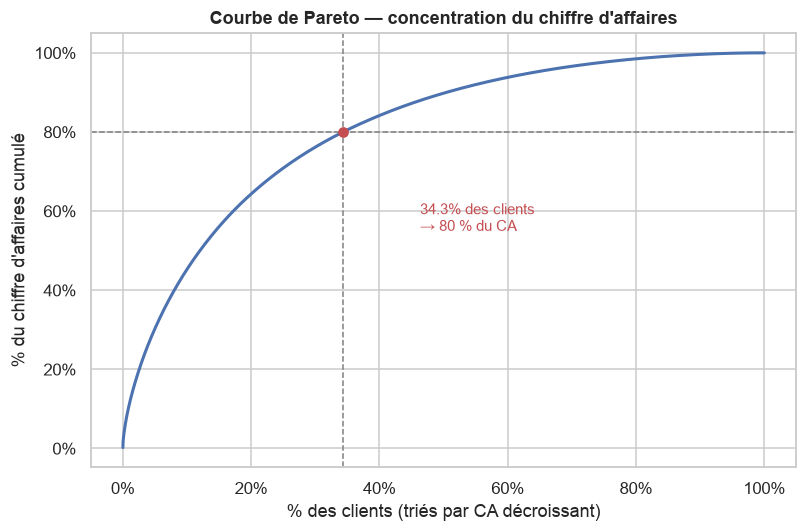

In [27]:
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(client_share * 100, cum_share * 100, color="#4C72B0", linewidth=2)
ax.axhline(80, color="grey", linestyle="--", linewidth=1)
ax.axvline(pct80 * 100, color="grey", linestyle="--", linewidth=1)
ax.scatter([pct80 * 100], [80], color="#C44E52", zorder=5)
ax.annotate(f"{pct80:.1%} des clients\n→ 80 % du CA", xy=(pct80 * 100, 80),
            xytext=(pct80 * 100 + 12, 55), fontsize=10, color="#C44E52")
ax.set_xlabel("% des clients (triés par CA décroissant)")
ax.set_ylabel("% du chiffre d'affaires cumulé")
ax.set_title("Courbe de Pareto — concentration du chiffre d'affaires")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
fig.tight_layout()
fig.savefig(FIGURES / "03_courbe_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** environ un tiers des clients porte 80 % du chiffre d'affaires —
une concentration réelle, mais plus proche de la règle 80/20 classique
qu'extrême. Note méthodologique : une première estimation faite (par erreur)
depuis le ledger transactionnel tronqué donnait 22,8 %, une concentration
artificiellement plus forte — la troncature de `transactions.csv` (Étape 3)
n'affecte pas tous les clients au même degré, ce qui gonflait artificiellement
l'écart entre gros et petits comptes. Le chiffre fiable est celui calculé ici,
depuis `total_spent`. Il reste un candidat naturel de segment "VIP" pour le
Jour 2, mais un tiers de la base, pas un cinquième.

### Saisonnalité : chiffre d'affaires mensuel sur toute la période

`transactions.csv` étant tronqué au niveau des lignes (Étape 3), le CA
mensuel qui en est tiré ne peut pas être présenté en euros absolus sans
induire en erreur — il sous-estime systématiquement le vrai chiffre
d'affaires. On l'affiche donc en **indice base 100** (moyenne de la période
= 100). Le plateau et les pics de juin ont été validés indépendamment (Étape
3, Test 6, sur le sous-groupe à lignes complètes) ; la phase de croissance
2022-2024 n'a pas pu l'être de la même façon, ce sous-groupe n'ayant quasiment
aucun client actif avant mi-2024 (Étape 3, Test 5).

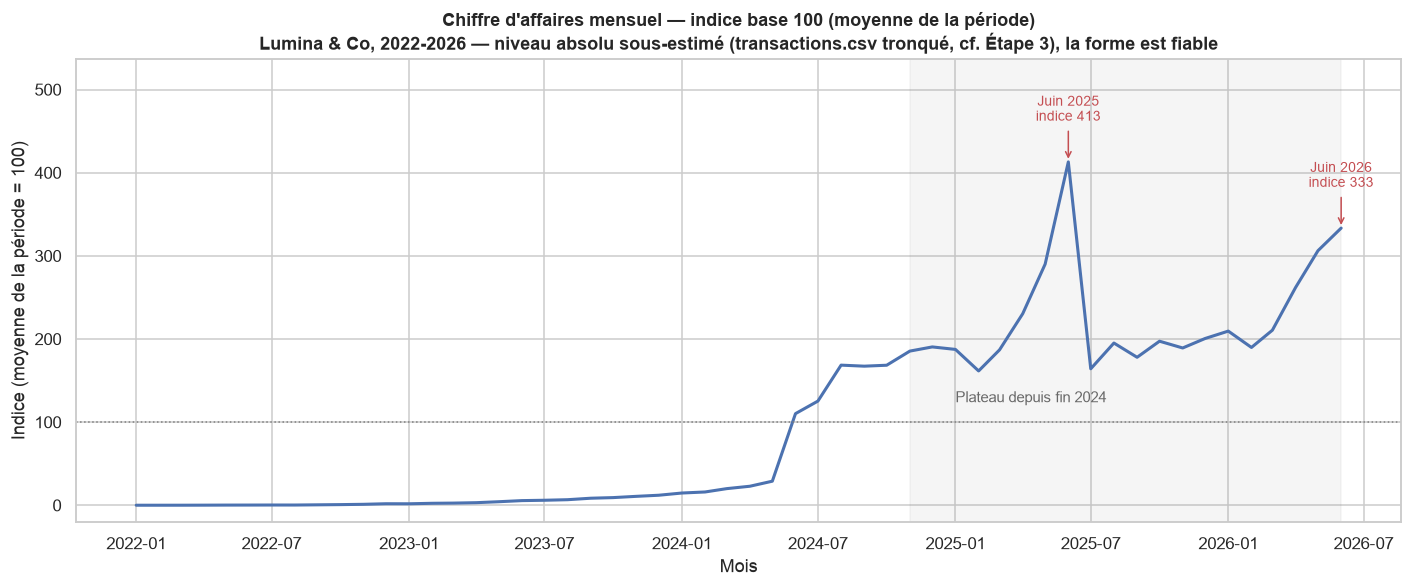

In [28]:
monthly_revenue = (
    sales_all.set_index("invoice_date")["line_total"]
    .resample("MS")
    .sum()
)
monthly_index = monthly_revenue / monthly_revenue.mean() * 100

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(monthly_index.index, monthly_index.values, color="#4C72B0", linewidth=2)
ax.axhline(100, color="grey", linestyle=":", linewidth=1)
ax.set_title(
    "Chiffre d'affaires mensuel — indice base 100 (moyenne de la période)\n"
    "Lumina & Co, 2022-2026 — niveau absolu sous-estimé (transactions.csv tronqué, cf. Étape 3), la forme est fiable"
)
ax.set_xlabel("Mois")
ax.set_ylabel("Indice (moyenne de la période = 100)")
ax.set_ylim(top=monthly_index.max() * 1.3)
ax.axvspan(pd.Timestamp("2024-11-01"), monthly_index.index.max(), color="grey", alpha=0.08)
ax.text(pd.Timestamp("2025-01-01"), monthly_index.max() * 0.3,
        "Plateau depuis fin 2024", fontsize=10, color="dimgrey")

for year in [2025, 2026]:
    june = pd.Timestamp(f"{year}-06-01")
    if june in monthly_index.index:
        ax.annotate(f"Juin {year}\nindice {monthly_index[june]:.0f}",
                    xy=(june, monthly_index[june]),
                    xytext=(june, monthly_index[june] + monthly_index.max() * 0.12),
                    ha="center", fontsize=9, color="#C44E52",
                    arrowprops=dict(arrowstyle="->", color="#C44E52"))

fig.tight_layout()
fig.savefig(FIGURES / "04_ca_mensuel.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** forte croissance de 2022 à fin 2024, puis un plateau net. Le
motif se répète chaque année en juin, où l'indice bondit nettement au-dessus
du plateau (pic net en juin 2025 et juin 2026) — cohérent avec une opération
commerciale récurrente (soldes d'été ?) plutôt qu'un simple bruit statistique.
Le plateau et les pics de juin ont été confirmés indépendamment à l'Étape 3
sur un sous-groupe de clients dont les données ne sont pas tronquées ; la
pente de la croissance 2022-2024 repose, elle, uniquement sur la source
tronquée et doit être lue avec plus de prudence. **La stagnation évoquée par
le CMO est donc réelle et visible dans les données**, pas une impression —
même si son niveau exact en euros reste à établir avec la finance, à partir
des systèmes source plutôt que de cet export. Implication marketing : la
croissance ne peut plus venir d'un effet de base qui grossit organiquement —
il faut soit élargir la base, soit augmenter la valeur par client existant
(d'où l'intérêt de la segmentation du Jour 2).

### Géographie : répartition des clients et comportements d'achat par pays

In [29]:
country_counts = customers["country"].value_counts()
top_countries = country_counts.head(10)
print(top_countries)
print(f"\nPart de la France : {country_counts['France'] / len(customers):.1%}")

country
France            45904
Germany             918
United Kingdom      760
Spain               291
Portugal            211
Belgium             203
Switzerland         184
Sweden              171
Netherlands         166
Italy               136
Name: count, dtype: int64

Part de la France : 91.3%


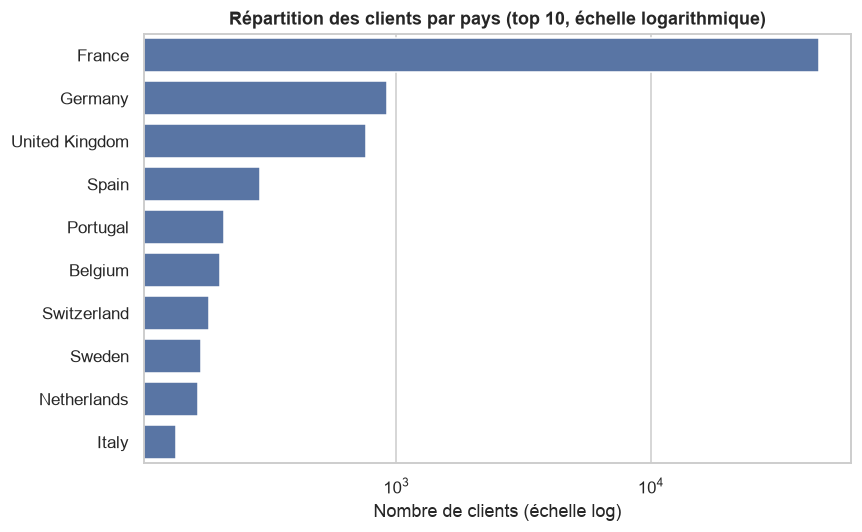

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, color="#4C72B0")
ax.set_xscale("log")
ax.set_xlabel("Nombre de clients (échelle log)")
ax.set_ylabel("")
ax.set_title("Répartition des clients par pays (top 10, échelle logarithmique)")
fig.tight_layout()
fig.savefig(FIGURES / "05_repartition_pays.png", dpi=150, bbox_inches="tight")
plt.show()

> **Point de vigilance :** la France représente 91,3 % de la base. Tous les
> segments RFM du Jour 2 seront donc, de fait, des segments de clients
> français. Les comportements des autres pays existent dans les données mais
> reposent sur des effectifs trop faibles (quelques centaines de clients) pour
> être généralisés — c'est une limite à mentionner explicitement dans la
> présentation finale.

In [31]:
country_metrics = (
    customers[["customer_id", "country"]]
    .merge(customer_metrics, on="customer_id", how="inner")
)
behavior_by_country = (
    country_metrics[country_metrics["country"].isin(top_countries.head(6).index)]
    .groupby("country")
    .agg(n_clients=("customer_id", "count"), panier_moyen=("avg_basket", "mean"), frequence_moyenne=("frequency", "mean"))
    .round(1)
    .sort_values("n_clients", ascending=False)
)
behavior_by_country

,n_clients,panier_moyen,frequence_moyenne
country,,,
France,45904,714.30,4.60
Germany,918,806.80,5.00
United Kingdom,760,730.30,4.80
Spain,291,788.80,3.40
Portugal,211,845.20,3.60
Belgium,203,644.40,5.60


**Lecture :** au-delà des volumes, les comportements (panier moyen,
fréquence) restent globalement du même ordre de grandeur d'un pays à
l'autre — il n'y a pas de marché étranger qui se démarque nettement, ce qui
renforce l'idée que le potentiel de croissance est surtout à chercher dans la
base française existante.

### Répartition du chiffre d'affaires par catégorie

Même limite que ci-dessus : on présente une **part relative** (%), pas un
montant absolu en euros — la troncature de `transactions.csv` affecte les
catégories de façon homogène (Étape 3, Test 4), donc la répartition en % est
fiable même si le total en € ne l'est pas.

In [32]:
category_revenue = (
    sales_all.groupby("category")["line_total"].sum().sort_values(ascending=False)
)
category_share = (category_revenue / category_revenue.sum() * 100).round(1)
print(category_share)

category
Visage       32.00
Corps        20.80
Coffret      20.60
Cheveux      11.40
Accessoire    8.10
Bain          7.10
Name: line_total, dtype: float64


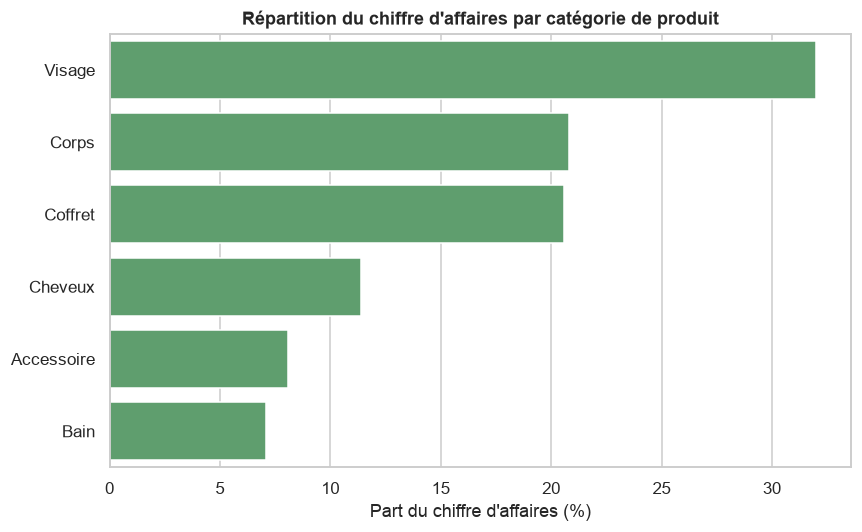

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=category_share.values, y=category_share.index, ax=ax, color="#55A868")
ax.set_xlabel("Part du chiffre d'affaires (%)")
ax.set_ylabel("")
ax.set_title("Répartition du chiffre d'affaires par catégorie de produit")
fig.tight_layout()
fig.savefig(FIGURES / "06_ca_par_categorie.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** "Visage" domine largement (environ un tiers du CA), suivi de
"Corps" et "Coffret" à des niveaux proches. "Bain" et "Accessoire" sont les
catégories les plus modestes. Cette répartition servira de point de
comparaison au Jour 2 pour voir si certains segments RFM ont une affinité
produit particulière.

### Relations entre variables : récence, fréquence, montant

In [34]:
corr_recency_monetary = customer_metrics[["recency_days", "monetary"]].corr().iloc[0, 1]
corr_freq_basket = customer_metrics[["frequency", "avg_basket"]].corr().iloc[0, 1]
print(f"Corrélation récence / montant dépensé : {corr_recency_monetary:.2f}")
print(f"Corrélation fréquence / panier moyen   : {corr_freq_basket:.2f}")

Corrélation récence / montant dépensé : -0.27
Corrélation fréquence / panier moyen   : 0.01


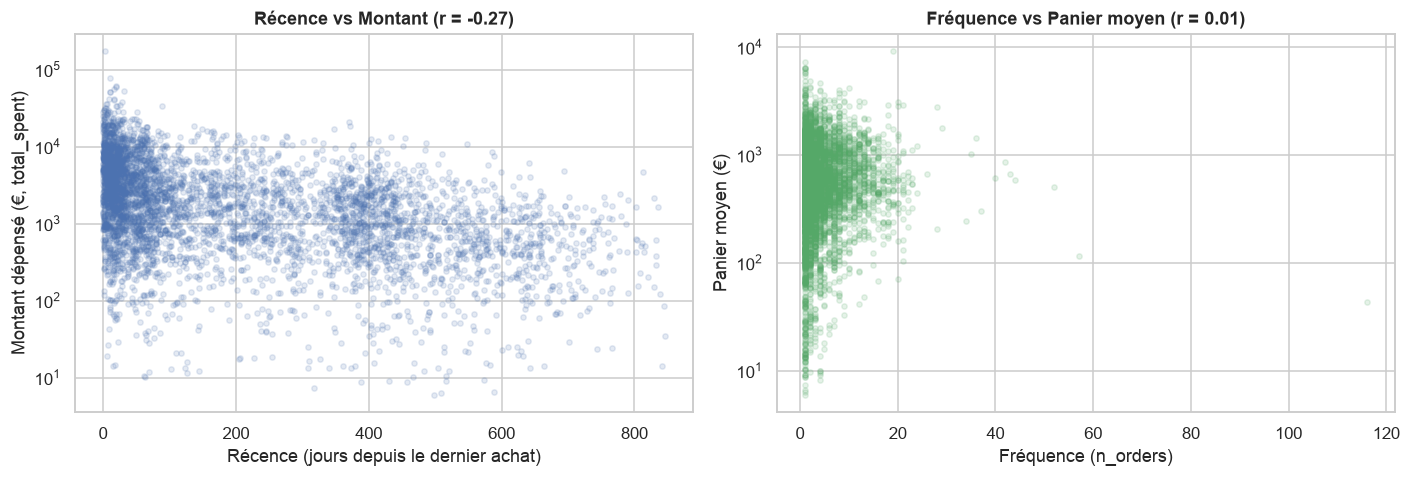

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sample = customer_metrics.sample(min(5000, len(customer_metrics)), random_state=42)
axes[0].scatter(sample["recency_days"], sample["monetary"], alpha=0.15, s=12, color="#4C72B0")
axes[0].set_xlabel("Récence (jours depuis le dernier achat)")
axes[0].set_ylabel("Montant dépensé (€, total_spent)")
axes[0].set_yscale("log")
axes[0].set_title(f"Récence vs Montant (r = {corr_recency_monetary:.2f})")

axes[1].scatter(sample["frequency"], sample["avg_basket"], alpha=0.15, s=12, color="#55A868")
axes[1].set_xlabel("Fréquence (n_orders)")
axes[1].set_ylabel("Panier moyen (€)")
axes[1].set_yscale("log")
axes[1].set_title(f"Fréquence vs Panier moyen (r = {corr_freq_basket:.2f})")

fig.tight_layout()
fig.savefig(FIGURES / "07_correlations_rfm.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** les deux relations n'ont pas le même profil. Fréquence et
panier moyen sont indépendants (r ≈ 0,01) : les clients qui commandent
souvent ne dépensent pas mécaniquement plus par commande. Récence et montant,
en revanche, affichent une corrélation négative modérée (r ≈ -0,27) : les
clients qui ont acheté plus récemment ont, historiquement, aussi plus
dépensé — cohérent avec le fait qu'un client qui a arrêté d'acheter il y a
longtemps a le plus souvent aussi cumulé moins de valeur (un client "one-shot"
ancien a une récence élevée et un `total_spent` mécaniquement faible). La
corrélation reste modérée, pas parfaite : ce n'est pas une redondance totale,
donc Récence et Montant restent deux axes utiles au RFM du Jour 2, mais ils
se recouvrent partiellement — à surveiller surtout sur les segments à récence
intermédiaire, où le montant varie le plus.

### Données zero-party : taux de remplissage et lien avec la valeur client

In [36]:
zero_party_cols = ["declared_preference", "age_bracket", "life_stage", "urban_density"]
fill_rates = (customers[zero_party_cols].notna().mean() * 100).round(1)
print(fill_rates)

declared_preference   38.10
age_bracket           42.70
life_stage            22.50
urban_density         19.80
dtype: float64


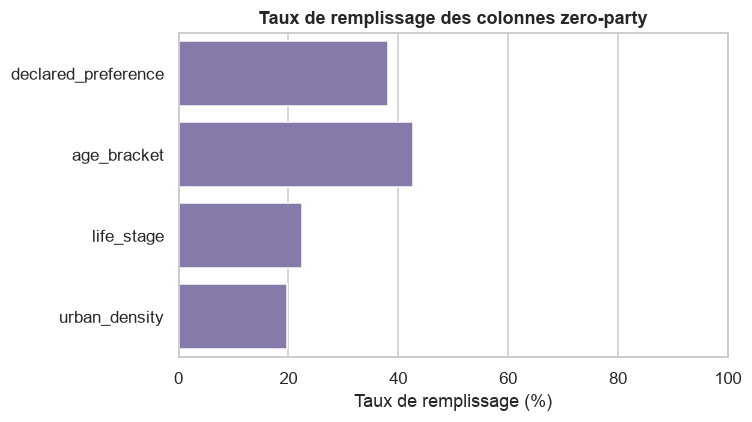

In [37]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=fill_rates.values, y=fill_rates.index, ax=ax, color="#8172B2")
ax.set_xlabel("Taux de remplissage (%)")
ax.set_ylabel("")
ax.set_title("Taux de remplissage des colonnes zero-party")
ax.set_xlim(0, 100)
fig.tight_layout()
fig.savefig(FIGURES / "08_remplissage_zero_party.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
customers_with_metrics = customers.merge(customer_metrics[["customer_id", "monetary", "frequency"]], on="customer_id", how="left")

rows = []
for col in zero_party_cols:
    filled = customers_with_metrics[col].notna()
    rows.append({
        "colonne": col,
        "taux_remplissage_%": fill_rates[col],
        "monetary_moyen_rempli": customers_with_metrics.loc[filled, "monetary"].mean(),
        "monetary_moyen_non_rempli": customers_with_metrics.loc[~filled, "monetary"].mean(),
    })
zero_party_vs_value = pd.DataFrame(rows).round(1)
zero_party_vs_value

,colonne,taux_remplissage_%,monetary_moyen_rempli,monetary_moyen_non_rempli
0,declared_preference,38.10,"3,380.60","3,369.40"
1,age_bracket,42.70,"3,356.20","3,386.80"
2,life_stage,22.50,"3,340.90","3,383.20"
3,urban_density,19.80,"3,407.80","3,365.30"


**Lecture :** le remplissage est faible (19,8 % à 42,7 % selon la colonne),
ce qui est attendu pour de la donnée zero-party (déclarative, non
obligatoire). Mais surtout, le montant dépensé moyen est quasiment identique
entre les clients qui ont renseigné une information et ceux qui ne l'ont pas
fait. **Déclarer ses préférences n'est donc pas un signal d'engagement ou de
valeur** — probablement plus lié au canal ou au moment d'acquisition qu'au
comportement d'achat.

## Étape 5 — Hypothèses marketing

Ces hypothèses seront testées via la segmentation RFM au Jour 2.

**1.** Je suppose que le plateau net de l'indice de CA mensuel depuis fin 2024
(indice base 100, confirmé indépendamment sur le sous-groupe de clients à
données non tronquées, Étape 3) implique que la croissance ne vient plus de
l'élargissement naturel de la base, ce qui suggère de prioriser des actions
sur la valeur des clients existants (montée en fréquence ou en panier) plutôt
que la seule acquisition.

**2.** Je suppose que la concentration du chiffre d'affaires (34,3 % des
clients génèrent 80 % du CA total_spent) implique l'existence d'un segment à
forte valeur clairement minoritaire — plus proche de la règle 80/20 classique
qu'extrême, une fois `customers.csv` utilisé comme source fiable — ce qui
suggère de créer un segment VIP dédié avec un traitement CRM différencié dès
le Jour 2, sur un tiers de la base plutôt qu'un cinquième.

**3.** Je suppose que le pic récurrent de juin (chaque année, nettement
au-dessus du plateau, visible aussi bien sur l'ensemble de la base que sur le
sous-groupe validé à l'Étape 3) implique un événement commercial saisonnier
prévisible, ce qui suggère de concentrer une partie du budget d'acquisition
et de relance CRM sur cette période plutôt que de le lisser uniformément sur
l'année.

**4.** Je suppose que la corrélation négative modérée entre récence et
montant dépensé (r ≈ -0,27, sur `customers.csv`) implique que les clients qui
ont arrêté d'acheter depuis longtemps sont aussi, en moyenne, ceux qui ont le
moins dépensé historiquement, ce qui suggère que le segment "à réactiver en
priorité" doit combiner récence élevée ET montant historique déjà correct
(pas seulement récence élevée) pour cibler les clients qui valent vraiment la
relance, plutôt que les anciens "one-shot" à faible valeur.

**5.** Je suppose que le fait que 91,3 % des clients soient français, combiné
à un remplissage zero-party non corrélé à la valeur (écart de `total_spent`
moyen < 1 % entre clients renseignés et non renseignés, sur les 4 colonnes),
implique que la segmentation du Jour 2 doit s'appuyer avant tout sur le
comportement transactionnel (RFM, à partir de `customers.csv`) plutôt que sur
la géographie ou les données déclaratives, ce qui suggère de traiter ces
dernières comme des axes d'enrichissement secondaires et non comme critères
de segmentation primaires.